# TVB Hybrid Simulation – Notebook 3 of 3
## External Stimulation, Per-Subnetwork Monitors, Connectome-Ordered Output, and Advanced Features

This is the third and final notebook in the TVB Hybrid Simulation API series.
Notebooks 1 and 2 covered subnetwork construction, projections, coupling functions,
and axonal delays.  Here we complete the picture with four advanced topics:

1. **External stimulation** — injecting spatiotemporal patterns (constant bias,
   pulse trains) into specific nodes and coupling variables of a subnetwork.
2. **Per-subnetwork monitors** — attaching TVB monitors directly to individual
   subnetworks so you can record from each population independently, without
   needing global monitors.
3. **Connectome-ordered output (merged mode)** — when every subnetwork carries
   `node_indices`, the simulator automatically assembles output into a full
   connectome array, placing each subnetwork at its original brain positions.
4. **Realistic inter-subnet wiring and reproducibility** — using structural
   connectivity to create anatomically informed projections between cortex and
   thalamus, and seeding the random-number generator for exact reproducibility.

By the end of this notebook you will be able to build a complete hybrid
simulation workflow from stimulus design through output alignment and
reproducible analysis.

In [ ]:
import warnings
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

from tvb.datatypes.connectivity import Connectivity
from tvb.datatypes import patterns, equations
from tvb.simulator import models, integrators, monitors
from tvb.simulator.hybrid import (
    Subnetwork,
    NetworkSet,
    Simulator,
    stimulus_utils,
)

/home/duke/src/tvb-root/tvb_library/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)
/home/duke/src/tvb-root/tvb_library/tvb/simulator/hybrid/__init__.py:166: UserWarning: Hybrid simulation is experimental: please report bugs or suggestions.
  warnings.warn(msg)


---
## Section 1 — External Stimulus: Constant Bias

The simplest stimulus is a constant (DC) input applied to one or more nodes.
We use `equations.Linear` with slope `a = 0` and intercept `b = 1.0`, which
evaluates to a time-independent value of 1.0 at every step.

The workflow has three parts:

1. Build the 5-node `Generic2dOscillator` subnet and a mini 5-region
   connectivity (required by `StimuliRegion` for spatial weighting).
2. Create the `StimuliRegion` pattern and attach it via
   `NetworkSet.add_stimulus()`.
3. Compare node 0 (stimulated) against node 4 (unstimulated) — and against
   the same node in a no-stimulus control run.

In [ ]:
n_nodes = 5
dt = 0.1

mini_conn = Connectivity(
    centres=np.ones((n_nodes, 3)),
    weights=np.ones((n_nodes, n_nodes)) * 0.1,
    tract_lengths=np.zeros((n_nodes, n_nodes)),
    region_labels=np.array([f"region_{i}" for i in range(n_nodes)]),
    speed=np.array([1.0]),
)
mini_conn.configure()

In [ ]:
temporal_const = equations.Linear()
temporal_const.parameters["a"] = 0.0   # no time ramp
temporal_const.parameters["b"] = 1.0   # constant amplitude

stim_weights = np.zeros(n_nodes)
stim_weights[0] = 1.0                  # only node 0 is stimulated

stim_pattern_const = patterns.StimuliRegion(
    temporal=temporal_const,
    connectivity=mini_conn,
    weight=stim_weights,
)

subnet_stim = Subnetwork(
    name="net",
    model=models.Generic2dOscillator(),
    scheme=integrators.EulerDeterministic(dt=dt),
    nnodes=n_nodes,
)
nets_stim = NetworkSet(subnets=[subnet_stim], projections=[])
nets_stim.add_stimulus(
    target_name="net",
    stimulus=stim_pattern_const,
    stimulus_cvar=np.r_[0],    # V = state variable 0
    projection_scale=1.0,
)
sim_stim = Simulator(
    nets=nets_stim,
    simulation_length=200.0,
    monitors=[monitors.Raw()],
)
sim_stim.configure()

zero_ic = [np.zeros((2, n_nodes, 1))]  # 2 state vars: V, W
((t_stim, y_stim),) = sim_stim.run(initial_conditions=zero_ic)

/tmp/ipykernel_794712/891823161.py:32: UserWarning: Global monitors are attached but subnetwork(s) ['net'] do not have node_indices set. Monitor output will be in concatenated subnetwork order, not original connectome order. Set node_indices on each Subnetwork to obtain connectome-ordered output.
  sim_stim.configure()


In [ ]:
subnet_ctrl = Subnetwork(
    name="net",
    model=models.Generic2dOscillator(),
    scheme=integrators.EulerDeterministic(dt=dt),
    nnodes=n_nodes,
)
nets_ctrl = NetworkSet(subnets=[subnet_ctrl], projections=[])
sim_ctrl = Simulator(
    nets=nets_ctrl,
    simulation_length=200.0,
    monitors=[monitors.Raw()],
)
sim_ctrl.configure()
((t_ctrl, y_ctrl),) = sim_ctrl.run(initial_conditions=zero_ic)

print(f"Output shape: {y_stim.shape}  →  (n_time, n_vois, n_nodes, 1)")

Output shape: (2000, 1, 5, 1)  →  (n_time, n_vois, n_nodes, 1)


/tmp/ipykernel_794712/2641361789.py:13: UserWarning: Global monitors are attached but subnetwork(s) ['net'] do not have node_indices set. Monitor output will be in concatenated subnetwork order, not original connectome order. Set node_indices on each Subnetwork to obtain connectome-ordered output.
  sim_ctrl.configure()


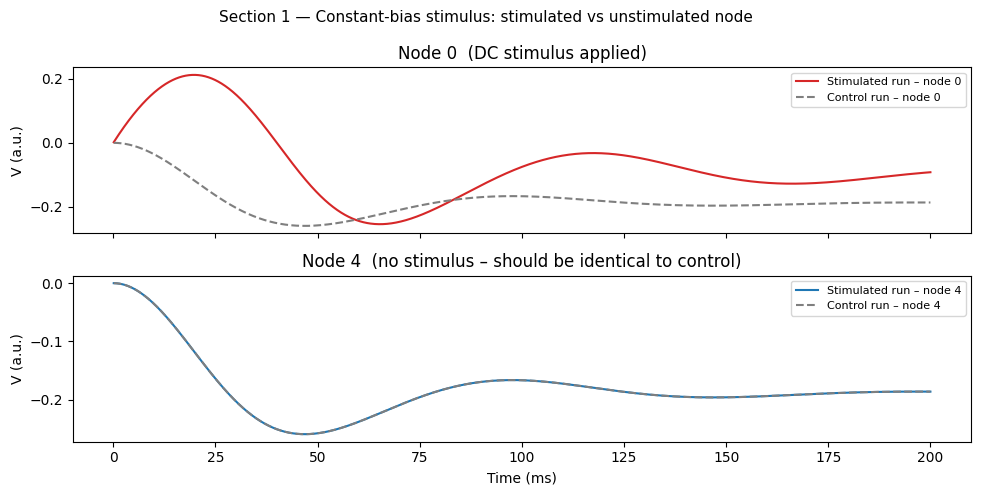

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t_stim, y_stim[:, 0, 0, 0], label="Stimulated run – node 0", color="tab:red")
axes[0].plot(t_ctrl, y_ctrl[:, 0, 0, 0], label="Control run – node 0", color="tab:grey", linestyle="--")
axes[0].set_ylabel("V (a.u.)")
axes[0].set_title("Node 0  (DC stimulus applied)")
axes[0].legend(fontsize=8)

axes[1].plot(t_stim, y_stim[:, 0, 4, 0], label="Stimulated run – node 4", color="tab:blue")
axes[1].plot(t_ctrl, y_ctrl[:, 0, 4, 0], label="Control run – node 4", color="tab:grey", linestyle="--")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("V (a.u.)")
axes[1].set_title("Node 4  (no stimulus – should be identical to control)")
axes[1].legend(fontsize=8)

fig.suptitle("Section 1 — Constant-bias stimulus: stimulated vs unstimulated node", fontsize=11)
plt.tight_layout()
plt.show()

**What to observe.**  Node 0 shifts its mean membrane potential and oscillation
envelope when the DC bias is applied (red vs grey).  Node 4 is indistinguishable
from the control because there are no inter-node projections in this standalone
subnet — spatial isolation is exact.

---
## Section 2 — Pulse-Train Stimulus

A `PulseTrain` temporal pattern creates a rectangular wave with user-defined
onset, period `T`, pulse width `tau`, and amplitude `amp`.  We first plot the
temporal envelope to verify the waveform, then run a 200 ms simulation and
compare the stimulated vs unstimulated nodes.

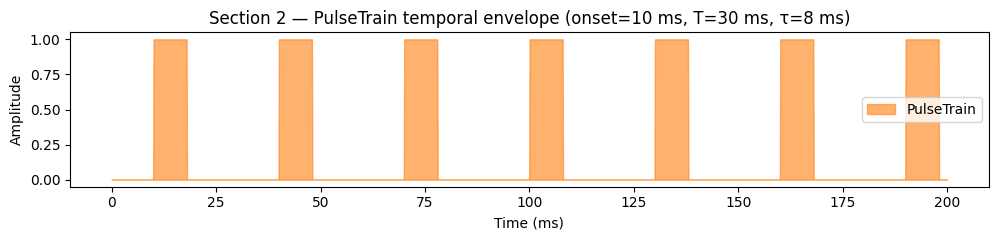

In [ ]:
temporal_pulse = equations.PulseTrain()
temporal_pulse.parameters["onset"] = 10.0   # first pulse starts at 10 ms
temporal_pulse.parameters["T"] = 30.0       # period: one pulse every 30 ms
temporal_pulse.parameters["tau"] = 8.0      # pulse width: 8 ms
temporal_pulse.parameters["amp"] = 1.0      # amplitude

# Evaluate the waveform directly using the equation's evaluate() method
t_eval = np.linspace(0.0, 200.0, 2000)
waveform = temporal_pulse.evaluate(t_eval)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.fill_between(t_eval, waveform, alpha=0.6, color="tab:orange", label="PulseTrain")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_title("Section 2 — PulseTrain temporal envelope (onset=10 ms, T=30 ms, τ=8 ms)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
stim_weights_pt = np.zeros(n_nodes)
stim_weights_pt[0] = 1.0

stim_pattern_pulse = patterns.StimuliRegion(
    temporal=temporal_pulse,
    connectivity=mini_conn,
    weight=stim_weights_pt,
)

subnet_pt = Subnetwork(
    name="net",
    model=models.Generic2dOscillator(),
    scheme=integrators.EulerDeterministic(dt=dt),
    nnodes=n_nodes,
)
nets_pt = NetworkSet(subnets=[subnet_pt], projections=[])
nets_pt.add_stimulus(
    target_name="net",
    stimulus=stim_pattern_pulse,
    stimulus_cvar=np.r_[0],
    projection_scale=2.0,
)
sim_pt = Simulator(
    nets=nets_pt,
    simulation_length=200.0,
    monitors=[monitors.Raw()],
)
sim_pt.configure()
((t_pt, y_pt),) = sim_pt.run(initial_conditions=zero_ic)

/tmp/ipykernel_794712/915730202.py:28: UserWarning: Global monitors are attached but subnetwork(s) ['net'] do not have node_indices set. Monitor output will be in concatenated subnetwork order, not original connectome order. Set node_indices on each Subnetwork to obtain connectome-ordered output.
  sim_pt.configure()


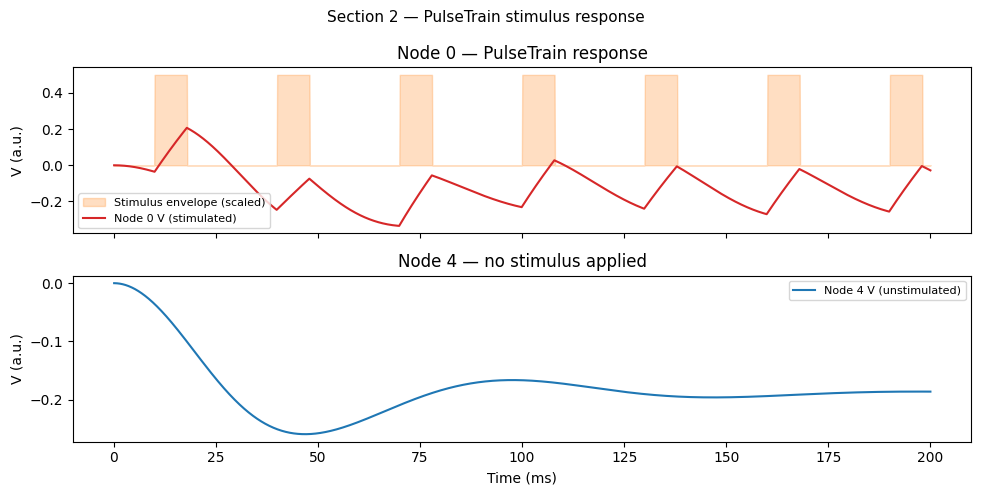

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].fill_between(t_eval, waveform * 0.5, alpha=0.25, color="tab:orange", label="Stimulus envelope (scaled)")
axes[0].plot(t_pt, y_pt[:, 0, 0, 0], color="tab:red", label="Node 0 V (stimulated)")
axes[0].set_ylabel("V (a.u.)")
axes[0].set_title("Node 0 — PulseTrain response")
axes[0].legend(fontsize=8)

axes[1].plot(t_pt, y_pt[:, 0, 4, 0], color="tab:blue", label="Node 4 V (unstimulated)")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("V (a.u.)")
axes[1].set_title("Node 4 — no stimulus applied")
axes[1].legend(fontsize=8)

fig.suptitle("Section 2 — PulseTrain stimulus response", fontsize=11)
plt.tight_layout()
plt.show()

The stimulated node's trajectory follows the pulse pattern — each pulse deflects
the membrane potential, creating a train of responses at the stimulus period.
The unstimulated node remains at the G2dO attractor with no external forcing.

---
## Section 3 — Spatial Selectivity

Here we show that the stimulus acts *only* on the nodes whose spatial weight is
non-zero.  We stimulate nodes 0 and 1 and leave nodes 2–4 untouched.  Because
there are no intra-subnet projections, the isolation is exact.

In [ ]:
stim_weights_sel = np.zeros(n_nodes)
stim_weights_sel[0] = 1.0
stim_weights_sel[1] = 1.0  # nodes 0 and 1 receive the stimulus

temporal_sel = equations.Linear()
temporal_sel.parameters["a"] = 0.0
temporal_sel.parameters["b"] = 1.5

stim_pattern_sel = patterns.StimuliRegion(
    temporal=temporal_sel,
    connectivity=mini_conn,
    weight=stim_weights_sel,
)

subnet_sel = Subnetwork(
    name="net",
    model=models.Generic2dOscillator(),
    scheme=integrators.EulerDeterministic(dt=dt),
    nnodes=n_nodes,
)
nets_sel = NetworkSet(subnets=[subnet_sel], projections=[])
nets_sel.add_stimulus(
    target_name="net",
    stimulus=stim_pattern_sel,
    stimulus_cvar=np.r_[0],
    projection_scale=1.0,
)
sim_sel = Simulator(
    nets=nets_sel,
    simulation_length=150.0,
    monitors=[monitors.Raw()],
)
sim_sel.configure()
((t_sel, y_sel),) = sim_sel.run(initial_conditions=zero_ic)

# Mean absolute V per node over the full run
mean_abs_v = np.abs(y_sel[:, 0, :, 0]).mean(axis=0)
print("Mean |V| per node:", np.round(mean_abs_v, 4))
print("Nodes 0,1 stimulated; nodes 2,3,4 control")

/tmp/ipykernel_794712/3661003127.py:33: UserWarning: Global monitors are attached but subnetwork(s) ['net'] do not have node_indices set. Monitor output will be in concatenated subnetwork order, not original connectome order. Set node_indices on each Subnetwork to obtain connectome-ordered output.
  sim_sel.configure()


Mean |V| per node: [0.1824 0.1824 0.1783 0.1783 0.1783]
Nodes 0,1 stimulated; nodes 2,3,4 control


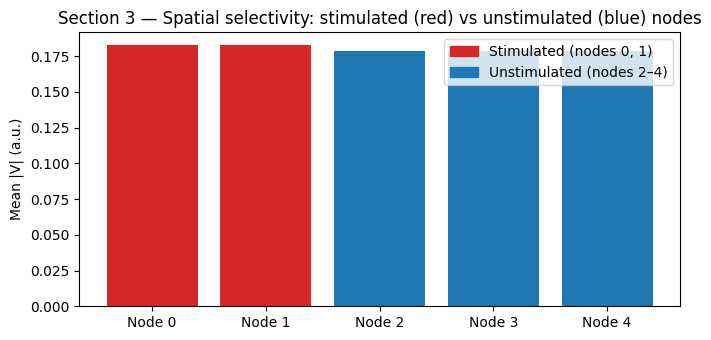

Assertion passed: stimulated nodes differ from unstimulated nodes.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["tab:red" if i < 2 else "tab:blue" for i in range(n_nodes)]
ax.bar(range(n_nodes), mean_abs_v, color=colors)
ax.set_xticks(range(n_nodes))
ax.set_xticklabels([f"Node {i}" for i in range(n_nodes)])
ax.set_ylabel("Mean |V| (a.u.)")
ax.set_title("Section 3 — Spatial selectivity: stimulated (red) vs unstimulated (blue) nodes")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="tab:red", label="Stimulated (nodes 0, 1)"),
    Patch(color="tab:blue", label="Unstimulated (nodes 2–4)"),
])
plt.tight_layout()
plt.show()

assert mean_abs_v[0] != mean_abs_v[2], "Stimulated node must differ from unstimulated node"
print("Assertion passed: stimulated nodes differ from unstimulated nodes.")

Nodes 0 and 1 show elevated mean absolute activity compared to nodes 2–4, which
remain at the G2dO free-running attractor levels.  The spatial weights in
`StimuliRegion` act as a binary gate: `weight[i] = 0` completely silences the
stimulus for node `i`.

---
## Section 4 — Effect of `projection_scale`

`projection_scale` multiplies the stimulus before it is added to the coupling
variable.  Sweeping it reveals the response relationship between stimulus
magnitude and the evoked mean activity.

In [ ]:
scales = [0.1, 0.5, 1.0, 2.0, 5.0]
mean_v_node0 = []

temporal_sweep = equations.Linear()
temporal_sweep.parameters["a"] = 0.0
temporal_sweep.parameters["b"] = 1.0

stim_weights_sweep = np.zeros(n_nodes)
stim_weights_sweep[0] = 1.0

for scale in scales:
    stim_pattern_sw = patterns.StimuliRegion(
        temporal=temporal_sweep,
        connectivity=mini_conn,
        weight=stim_weights_sweep,
    )
    sn = Subnetwork(
        name="net",
        model=models.Generic2dOscillator(),
        scheme=integrators.EulerDeterministic(dt=dt),
        nnodes=n_nodes,
    )
    nets_sw = NetworkSet(subnets=[sn], projections=[])
    nets_sw.add_stimulus(
        target_name="net",
        stimulus=stim_pattern_sw,
        stimulus_cvar=np.r_[0],
        projection_scale=scale,
    )
    sim_sw = Simulator(
        nets=nets_sw,
        simulation_length=100.0,
        monitors=[monitors.Raw()],
    )
    sim_sw.configure()
    ((_, y_sw),) = sim_sw.run(initial_conditions=zero_ic)
    mean_v_node0.append(y_sw[:, 0, 0, 0].mean())

print("Scales:", scales)
print("Mean V at node 0:", np.round(mean_v_node0, 4).tolist())

/tmp/ipykernel_794712/775611475.py:35: UserWarning: Global monitors are attached but subnetwork(s) ['net'] do not have node_indices set. Monitor output will be in concatenated subnetwork order, not original connectome order. Set node_indices on each Subnetwork to obtain connectome-ordered output.
  sim_sw.configure()


Scales: [0.1, 0.5, 1.0, 2.0, 5.0]
Mean V at node 0: [-0.163, -0.1133, -0.0483, 0.1207, 0.7141]


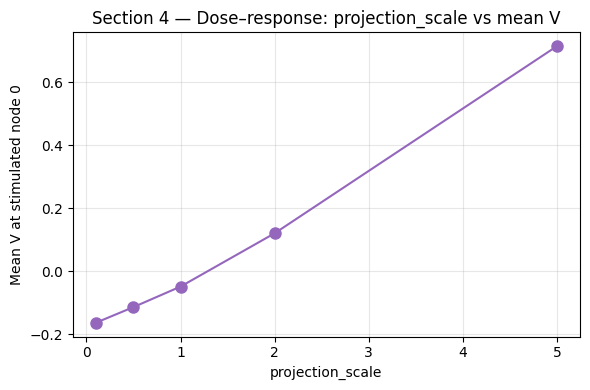

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(scales, mean_v_node0, "o-", color="tab:purple", markersize=8)
ax.set_xlabel("projection_scale")
ax.set_ylabel("Mean V at stimulated node 0")
ax.set_title("Section 4 — Response: projection_scale vs mean V")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As `projection_scale` increases, the effective stimulus amplitude grows and the
mean membrane potential of the stimulated node shifts monotonically.  At large
scales the attractor may be pushed far from its resting location.

---
## Section 5 — Per-Subnetwork Monitors (Recorders)

Global monitors collect data from all subnetworks in a single merged array.
Sometimes it is more convenient to monitor each subnetwork independently,
especially when models have different numbers of variables of interest.

The API:
1. Build the `Simulator` **without** passing `monitors=`.
2. Call `sim.configure()` so that each subnet is fully configured.
3. Call `subnet.add_monitor(tvb_monitor)` **after** configure — this wraps the
   monitor in a `Recorder` that accumulates data during the time loop.
4. The `Recorder` needs its sample-count pre-allocated: call
   `subnet.monitors[-1].configure(sim.simulation_length)`.
5. `sim.run()` returns `[]` (no global monitors) — retrieve data from each
   subnet's `Recorder` via `rec.to_arrays()`.

In [ ]:
n_jr = 10
n_g2d = 10

subnet_jr = Subnetwork(
    name="jansen",
    model=models.JansenRit(),
    scheme=integrators.HeunDeterministic(dt=0.1),
    nnodes=n_jr,
)
subnet_g2d = Subnetwork(
    name="g2d",
    model=models.Generic2dOscillator(),
    scheme=integrators.EulerDeterministic(dt=0.1),
    nnodes=n_g2d,
)

nets_rec = NetworkSet(subnets=[subnet_jr, subnet_g2d], projections=[])
sim_rec = Simulator(nets=nets_rec, simulation_length=100.0)   # no global monitors
sim_rec.configure()

# Attach TemporalAverage monitors AFTER configure()
tavg_jr = monitors.TemporalAverage(period=1.0)
tavg_g2d = monitors.TemporalAverage(period=1.0)

subnet_jr.add_monitor(tavg_jr)
subnet_jr.monitors[-1].configure(sim_rec.simulation_length)

subnet_g2d.add_monitor(tavg_g2d)
subnet_g2d.monitors[-1].configure(sim_rec.simulation_length)

# Run – no global monitors → empty list
results_rec = sim_rec.run(random_state=42)
assert results_rec == [], f"Expected empty list, got {results_rec}"
print("Global results (no monitors):", results_rec)

# Retrieve from per-subnet recorders
t_jr_rec, y_jr_rec = subnet_jr.monitors[0].to_arrays()
t_g2d_rec, y_g2d_rec = subnet_g2d.monitors[0].to_arrays()

print(f"JansenRit recorder:       t shape={t_jr_rec.shape}, y shape={y_jr_rec.shape}")
print(f"Generic2dOscillator rec:  t shape={t_g2d_rec.shape}, y shape={y_g2d_rec.shape}")

Global results (no monitors): []
JansenRit recorder:       t shape=(100,), y shape=(100, 4, 10, 1)
Generic2dOscillator rec:  t shape=(100,), y shape=(100, 1, 10, 1)


/home/duke/src/tvb-root/tvb_library/.venv/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: overflow encountered in _numba_dfun_jr
  return self.ufunc(*args, **kwargs)


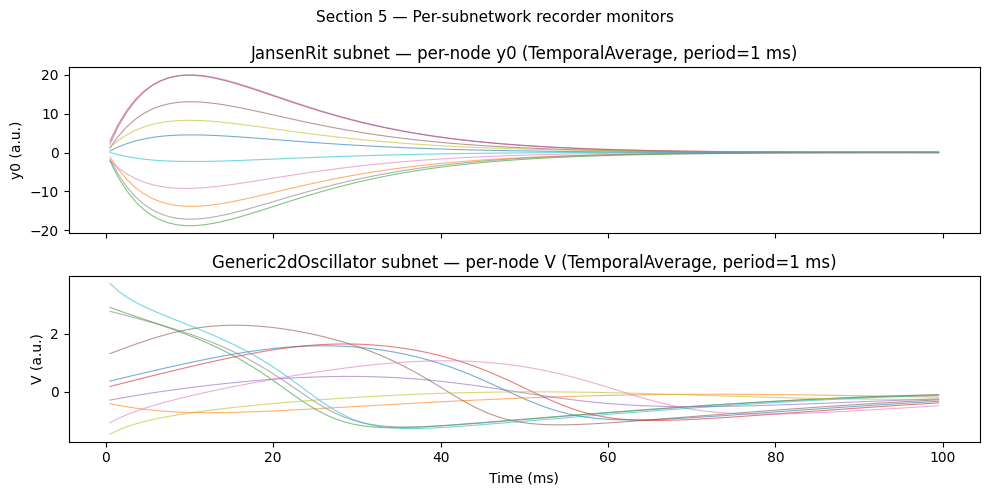

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# JansenRit VOI 0 (y0) for all 10 nodes
for node in range(n_jr):
    axes[0].plot(t_jr_rec, y_jr_rec[:, 0, node, 0], alpha=0.6, linewidth=0.8)
axes[0].set_ylabel("y0 (a.u.)")
axes[0].set_title("JansenRit subnet — per-node y0 (TemporalAverage, period=1 ms)")

# Generic2dOscillator VOI 0 (V) for all 10 nodes
for node in range(n_g2d):
    axes[1].plot(t_g2d_rec, y_g2d_rec[:, 0, node, 0], alpha=0.6, linewidth=0.8)
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("V (a.u.)")
axes[1].set_title("Generic2dOscillator subnet — per-node V (TemporalAverage, period=1 ms)")

fig.suptitle("Section 5 — Per-subnetwork recorder monitors", fontsize=11)
plt.tight_layout()
plt.show()

Each subnet's `Recorder` collects data independently, preserving the full
`(n_time, n_vois, n_nodes, 1)` shape.  This is especially useful for
heterogeneous networks where VOI counts differ between populations.

---
## Section 6 — Connectome-Ordered Output (Merged Mode)

When **every** subnetwork has `node_indices` set and all subnetworks share the
**same number of variables of interest**, the simulator enters *merged mode*.
Instead of concatenating subnetwork outputs, the global monitor places each
subnetwork's data at its original connectome positions, yielding a full
`(n_time, n_vois, n_total_nodes, 1)` array.

We partition the default 76-region TVB connectivity into a random cortex/thalamus
split, run both populations in parallel, and verify the output is connectome-
ordered.

In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    conn76 = Connectivity.from_file()
    conn76.configure()

n_total = conn76.number_of_regions
print(f"Total connectome regions: {n_total}")

np.random.seed(42)
ix = np.random.randint(0, 2, size=n_total)
ctx_idx = np.where(ix == 0)[0]
thal_idx = np.where(ix == 1)[0]
print(f"Cortex nodes: {len(ctx_idx)},  Thalamus nodes: {len(thal_idx)}")

2026-04-07 15:16:14,576 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.


Total connectome regions: 76
Cortex nodes: 37,  Thalamus nodes: 39


In [ ]:
# Both models must expose the same number of VOIs.
# JansenRit default VOIs: ('y0','y1','y2','y3') → we keep 2
# ReducedSetFitzHughNagumo default VOIs: ('xi','alpha') → already 2

JR = models.JansenRit
jr_vois = list(JR().variables_of_interest[:2])   # ['y0', 'y1']

FHN = models.ReducedSetFitzHughNagumo
fhn_vois = ["xi", "alpha"]                        # default 2 VOIs

print(f"JansenRit VOIs for merged mode: {jr_vois}")
print(f"ReducedSetFitzHughNagumo VOIs:  {fhn_vois}")

cortex = Subnetwork(
    name="cortex",
    model=JR(variables_of_interest=jr_vois),
    scheme=integrators.HeunDeterministic(dt=0.1),
    nnodes=len(ctx_idx),
    node_indices=ctx_idx,      # ← required for merged mode
)
thalamus = Subnetwork(
    name="thalamus",
    model=FHN(variables_of_interest=fhn_vois),
    scheme=integrators.HeunDeterministic(dt=0.1),
    nnodes=len(thal_idx),
    node_indices=thal_idx,     # ← required for merged mode
)

nets_merged = NetworkSet(subnets=[cortex, thalamus], projections=[])
print(f"\nMerged mode active: {nets_merged._is_merged_mode()}")

JansenRit VOIs for merged mode: ['y0', 'y1']
ReducedSetFitzHughNagumo VOIs:  ['xi', 'alpha']

Merged mode active: True


In [ ]:
tavg_merged = monitors.TemporalAverage(period=1.0)
sim_merged = Simulator(
    nets=nets_merged,
    simulation_length=10.0,
    monitors=[tavg_merged],
)
sim_merged.configure()

# Use explicit zero ICs to avoid FHN overflow with random initialisation
# JR state vars: (y0,y1,y2,y3,y4,y5) → shape (6, n_ctx, 1)
# FHN state vars: (xi,eta,alpha,beta)  → shape (4, n_thal, 3)   [3 modes]
ic_ctx = np.zeros((6, len(ctx_idx), 1))
ic_thal = np.zeros((4, len(thal_idx), 3))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ((t_merged, y_merged),) = sim_merged.run(initial_conditions=[ic_ctx, ic_thal])

print(f"\nMerged output shape: {y_merged.shape}")
print(f"Expected:            (10, 2, {n_total}, 1)  →  (n_time, n_vois, n_regions, 1)")

# Verify connectome ordering: cortex data at cortex indices
cortex_activity = y_merged[:, :, ctx_idx, :]
thalamus_activity = y_merged[:, :, thal_idx, :]
print(f"Cortex slice shape:   {cortex_activity.shape}")
print(f"Thalamus slice shape: {thalamus_activity.shape}")


Merged output shape: (10, 2, 76, 1)
Expected:            (10, 2, 76, 1)  →  (n_time, n_vois, n_regions, 1)
Cortex slice shape:   (10, 2, 37, 1)
Thalamus slice shape: (10, 2, 39, 1)


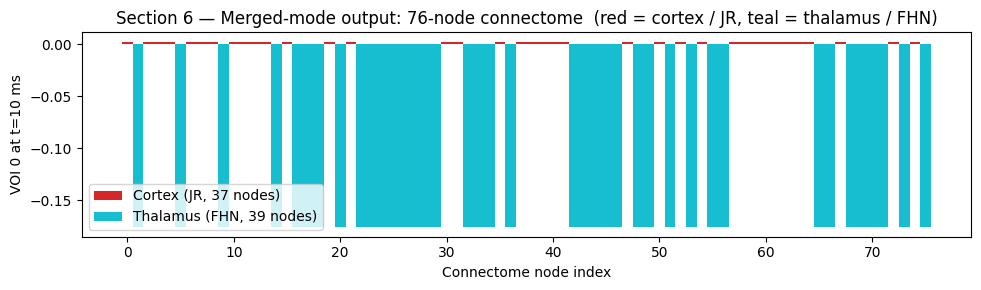

In [ ]:
activity_map = y_merged[-1, 0, :, 0]   # last time step, VOI 0, mode 0

fig, ax = plt.subplots(figsize=(10, 3))
ctx_set = set(ctx_idx.tolist())
# Plot cortex and thalamus bars separately to allow per-group coloring
ax.bar(ctx_idx,  activity_map[ctx_idx],  color="tab:red",  width=1.0, label=f"Cortex (JR, {len(ctx_idx)} nodes)")
ax.bar(thal_idx, activity_map[thal_idx], color="tab:cyan", width=1.0, label=f"Thalamus (FHN, {len(thal_idx)} nodes)")
ax.set_xlabel("Connectome node index")
ax.set_ylabel("VOI 0 at t=10 ms")
ax.set_title(f"Section 6 — Merged-mode output: {n_total}-node connectome  "
             f"(red = cortex / JR, teal = thalamus / FHN)")
ax.legend()
plt.tight_layout()
plt.show()

The bar chart shows which regions belong to which population.  The key insight
is that the output tensor has shape `(n_time, n_vois, 76, 1)` — ready for any
downstream TVB analysis tool that expects full-connectome arrays — without any
manual index bookkeeping on the user's side.

---
## Section 7 — `add_projection_from_connectivity`

This convenience method extracts the relevant weight sub-matrix and fibre
lengths from a global `Connectivity` object and wires two subnetworks together.
Here we re-use the cortex/thalamus partition from Section 6 and add a
cortex → thalamus projection driven by JansenRit's y1 (pyramidal output)
targeting FHN's xi (excitatory variable).

We compare the thalamus response *with* vs *without* the cortical projection
to verify that the anatomical wiring changes the dynamics.

In [ ]:
cortex_iso = Subnetwork(
    name="cortex",
    model=JR(variables_of_interest=jr_vois),
    scheme=integrators.HeunDeterministic(dt=0.1),
    nnodes=len(ctx_idx),
    node_indices=ctx_idx,
)
thalamus_iso = Subnetwork(
    name="thalamus",
    model=FHN(variables_of_interest=fhn_vois),
    scheme=integrators.HeunDeterministic(dt=0.1),
    nnodes=len(thal_idx),
    node_indices=thal_idx,
)
nets_iso = NetworkSet(subnets=[cortex_iso, thalamus_iso], projections=[])
tavg_iso = monitors.TemporalAverage(period=1.0)
sim_iso = Simulator(nets=nets_iso, simulation_length=100.0, monitors=[tavg_iso])
sim_iso.configure()

ic_ctx100  = np.zeros((6, len(ctx_idx), 1))
ic_thal100 = np.zeros((4, len(thal_idx), 3))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ((t_iso, y_iso),) = sim_iso.run(initial_conditions=[ic_ctx100, ic_thal100])

In [ ]:
cortex_wired = Subnetwork(
    name="cortex",
    model=JR(variables_of_interest=jr_vois),
    scheme=integrators.HeunDeterministic(dt=0.1),
    nnodes=len(ctx_idx),
    node_indices=ctx_idx,
)
thalamus_wired = Subnetwork(
    name="thalamus",
    model=FHN(variables_of_interest=fhn_vois),
    scheme=integrators.HeunDeterministic(dt=0.1),
    nnodes=len(thal_idx),
    node_indices=thal_idx,
)
nets_wired = NetworkSet(subnets=[cortex_wired, thalamus_wired], projections=[])

# Add cortex→thalamus projection drawn from the 76-region connectivity matrix
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    nets_wired.add_projection_from_connectivity(
        source_name="cortex",
        target_name="thalamus",
        connectivity=conn76,
        source_cvar="y1",          # JansenRit pyramidal output
        target_cvar="xi",          # FHN excitatory variable
        source_indices=ctx_idx,
        target_indices=thal_idx,
        scale=1e-4,
        cv=3.0,
        dt=0.1,
    )

print(f"Number of projections in wired NetworkSet: {len(nets_wired.projections)}")

tavg_wired = monitors.TemporalAverage(period=1.0)
sim_wired = Simulator(nets=nets_wired, simulation_length=100.0, monitors=[tavg_wired])
sim_wired.configure()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ((t_wired, y_wired),) = sim_wired.run(initial_conditions=[ic_ctx100, ic_thal100])

Number of projections in wired NetworkSet: 1


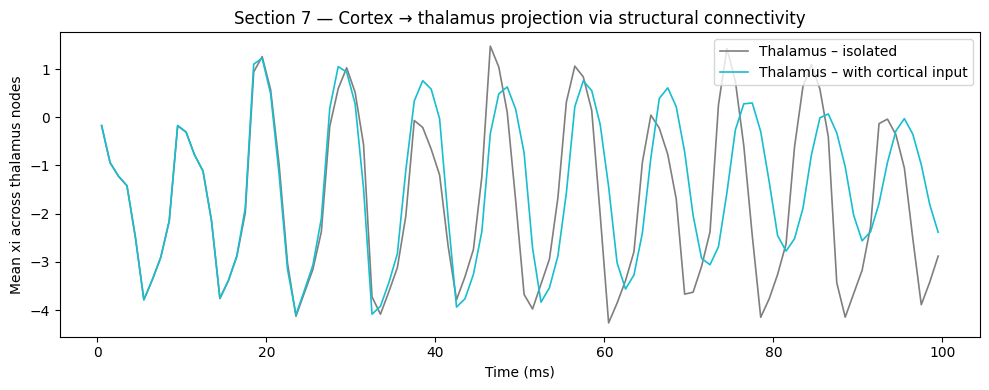

RMS difference between isolated and wired thalamus activity: 1.309453


In [ ]:
mean_thal_iso   = y_iso[:, 0, thal_idx, 0].mean(axis=1)
mean_thal_wired = y_wired[:, 0, thal_idx, 0].mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_iso,   mean_thal_iso,   label="Thalamus – isolated",      color="tab:grey",  linewidth=1.2)
ax.plot(t_wired, mean_thal_wired, label="Thalamus – with cortical input", color="tab:cyan", linewidth=1.2)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Mean xi across thalamus nodes")
ax.set_title("Section 7 — Cortex → thalamus projection via structural connectivity")
ax.legend()
plt.tight_layout()
plt.show()

diff_rms = np.sqrt(np.mean((mean_thal_iso - mean_thal_wired) ** 2))
print(f"RMS difference between isolated and wired thalamus activity: {diff_rms:.6f}")

The two curves diverge over time as cortical activity modulates the thalamic
excitatory state via the anatomically weighted projection.  The effect size
depends on `scale` and the actual non-zero weights in the chosen connectivity
sub-matrix.

---
## Section 8 — Reproducibility with `random_state`

The `sim.run(random_state=seed)` argument controls how the simulator generates
random initial conditions.  Passing the same integer seed produces bit-identical
trajectories; passing `None` (the default) draws fresh random ICs each run.

This is essential for:
- **Unit tests** — verifying that code changes don't alter results.
- **Parameter sweeps** — ensuring different conditions differ only in the
  parameter being swept, not in random ICs.

In [ ]:
def make_g2d_sim(simulation_length=100.0):
    sn = Subnetwork(
        name="net",
        model=models.Generic2dOscillator(),
        scheme=integrators.EulerDeterministic(dt=0.1),
        nnodes=10,
    )
    nets = NetworkSet(subnets=[sn], projections=[])
    sim = Simulator(nets=nets, simulation_length=simulation_length, monitors=[monitors.Raw()])
    sim.configure()
    return sim

In [ ]:
sim_r1 = make_g2d_sim()
sim_r2 = make_g2d_sim()
((t_r1, y_r1),) = sim_r1.run(random_state=42)
((t_r2, y_r2),) = sim_r2.run(random_state=42)

assert np.allclose(y_r1, y_r2), "Same random_state must produce identical results"
print(f"Same seed (42): results identical → {np.allclose(y_r1, y_r2)}")

Same seed (42): results identical → True


/tmp/ipykernel_794712/3405884503.py:10: UserWarning: Global monitors are attached but subnetwork(s) ['net'] do not have node_indices set. Monitor output will be in concatenated subnetwork order, not original connectome order. Set node_indices on each Subnetwork to obtain connectome-ordered output.
  sim.configure()


In [ ]:
sim_r3 = make_g2d_sim()
sim_r4 = make_g2d_sim()
((_, y_r3),) = sim_r3.run(random_state=None)
((_, y_r4),) = sim_r4.run(random_state=None)
print(f"None seed: results identical → {np.allclose(y_r3, y_r4)}  (expected: False)")

None seed: results identical → False  (expected: False)


/tmp/ipykernel_794712/3405884503.py:10: UserWarning: Global monitors are attached but subnetwork(s) ['net'] do not have node_indices set. Monitor output will be in concatenated subnetwork order, not original connectome order. Set node_indices on each Subnetwork to obtain connectome-ordered output.
  sim.configure()


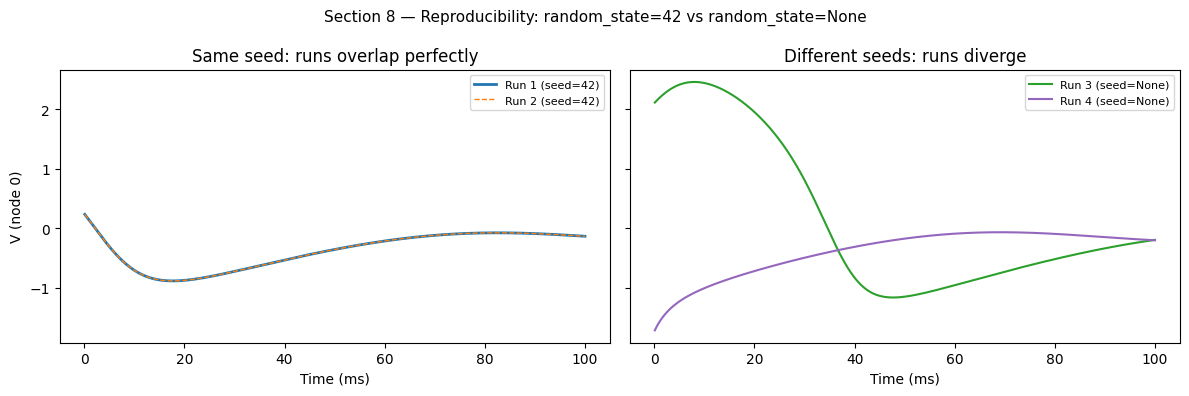

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

node = 0  # plot node 0
axes[0].plot(t_r1, y_r1[:, 0, node, 0], color="tab:blue",   linewidth=2.0,  label="Run 1 (seed=42)")
axes[0].plot(t_r2, y_r2[:, 0, node, 0], color="tab:orange", linewidth=1.0, linestyle="--", label="Run 2 (seed=42)")
axes[0].set_title("Same seed: runs overlap perfectly")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("V (node 0)")
axes[0].legend(fontsize=8)

axes[1].plot(t_r1, y_r3[:, 0, node, 0], color="tab:green",  linewidth=1.5,  label="Run 3 (seed=None)")
axes[1].plot(t_r1, y_r4[:, 0, node, 0], color="tab:purple", linewidth=1.5,  label="Run 4 (seed=None)")
axes[1].set_title("Different seeds: runs diverge")
axes[1].set_xlabel("Time (ms)")
axes[1].legend(fontsize=8)

fig.suptitle("Section 8 — Reproducibility: random_state=42 vs random_state=None", fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated the full advanced feature set of the TVB Hybrid
Simulation API:

| Topic | Key API |
|---|---|
| External stimulus (constant) | `equations.Linear`, `StimuliRegion`, `NetworkSet.add_stimulus()` |
| External stimulus (pulse train) | `equations.PulseTrain`, `temporal.evaluate(t)` |
| Spatial selectivity | `StimuliRegion(weight=...)` — zero weights silence nodes |
| Stimulus amplitude | `projection_scale` argument to `add_stimulus()` |
| Per-subnet monitor | `subnet.add_monitor()` after `sim.configure()`, `Recorder.to_arrays()` |
| Merged / connectome-ordered output | `node_indices` on every subnet, same `len(variables_of_interest)` |
| Structural wiring | `NetworkSet.add_projection_from_connectivity()` |
| Reproducibility | `sim.run(random_state=42)` |

### Key constraints to remember

- **Do not call `subnet.configure()` manually** before `Simulator.configure()`;
  the simulator handles it.  Exception: if you call `subnet.add_monitor()`
  after `sim.configure()`, the subnet is already configured — remember to also
  call `subnet.monitors[-1].configure(sim.simulation_length)` on the new recorder.
- **Merged mode requires identical VOI counts** across all subnetworks.  Use
  `model(variables_of_interest=[...])` to slice as needed.
- **`StimuliRegion.weight`** must have shape `(nnodes_of_subnet,)`, matching
  the subnet size — not the global connectivity size.
- **`ReducedSetFitzHughNagumo`** has 3 modes; in merged mode the simulator
  automatically sums over modes before placing data in the connectome array.

### Further reading

- [TVB Documentation](https://docs.thevirtualbrain.org)
- [TVB Scientific Publications](https://www.thevirtualbrain.org/tvb/zwei/neuroscience-publications)
- Notebooks 1 & 2 in this series: `simulate_hybrid_getting_started.ipynb`,
  `simulate_hybrid_coupling_and_delays.ipynb`